In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

d:\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\VietUser\.cache\kagglehub\datasets\chiragsaipanuganti\utkface\versions\2


In [4]:
import os
import shutil
import pandas as pd
import random
import cv2
import mediapipe as mp

# CONFIG
SOURCE_PATH = r"C:\Users\VietUser\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1\utkface_aligned_cropped\UTKFace"
OUTPUT_PATH = r"D:\HCSDLDPT\BTL\dataset"

AGE_MIN = 1
AGE_MAX = 10
MAIN_SAMPLES = 520
TEST_SAMPLES = 100
MIN_RATIO = 0.7
MAX_RATIO = 1.3

# THÔNG SỐ LỌC DIỆN TÍCH
FACE_AREA_THRESHOLD = 0.7  # Tỷ lệ diện tích mặt/ảnh >= 70%

random.seed(42)

# Khởi tạo MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

# Tạo folder
for folder in ["FullData", "MainData", "Test"]:
    folder_path = os.path.join(OUTPUT_PATH, folder)
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
    os.makedirs(folder_path, exist_ok=True)

# Parse dataset + TÍCH HỢP LỌC DIỆN TÍCH
data = []
count_total = 0
count_rejected_area = 0

print("Đang quét và lọc ảnh theo diện tích khuôn mặt...")

for file in os.listdir(SOURCE_PATH):
    if not file.lower().endswith(".jpg"):
        continue

    count_total += 1
    parts = file.split("_")
    if len(parts) < 4:
        continue

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except:
        continue

    # Chỉ xử lý nếu nằm trong độ tuổi quy định
    if AGE_MIN <= age <= AGE_MAX:
        # Bước lọc diện tích khuôn mặt
        img_path = os.path.join(SOURCE_PATH, file)
        image = cv2.imread(img_path)
        
        if image is None:
            continue

        # Chuyển BGR sang RGB cho MediaPipe
        results = face_detector.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        is_qualified = False
        if results.detections:
            # Lấy khuôn mặt có diện tích lớn nhất (thường là mặt chính)
            detection = results.detections[0]
            bbox = detection.location_data.relative_bounding_box
            
            # MediaPipe trả về tọa độ chuẩn hóa (0-1), nên diện tích = width * height
            face_area_ratio = bbox.width * bbox.height
            
            if face_area_ratio >= FACE_AREA_THRESHOLD:
                is_qualified = True
            else:
                count_rejected_area += 1
        else:
            count_rejected_area += 1

        if is_qualified:
            data.append({
                "filename": file,
                "source_id": file,
                "age": age,
                "gender": gender,
                "race": race,
                "timestamp": "_".join(parts[3:])
            })

face_detector.close() # Giải phóng bộ nhớ detector

df = pd.DataFrame(data)

print("-" * 30)
print(f"Tổng số ảnh quét: {count_total}")
print(f"Số ảnh bị loại do mặt nhỏ (< {FACE_AREA_THRESHOLD*100}%): {count_rejected_area}")
print(f"Số ảnh đạt chuẩn sau lọc: {len(df)}")
print("-" * 30)

# --- GIỮ NGUYÊN CÁC HÀM copy_and_save VÀ distribution_sample CỦA BẠN ---

def copy_and_save(df_subset, folder_name):
    dst_folder = os.path.join(OUTPUT_PATH, folder_name)
    rows = []
    for _, row in df_subset.iterrows():
        src = os.path.join(SOURCE_PATH, row["filename"])
        dst = os.path.join(dst_folder, row["filename"])
        if os.path.exists(src):
            shutil.copy2(src, dst)
            rows.append(row.to_dict())
    df_out = pd.DataFrame(rows).reset_index(drop=True)
    if not df_out.empty:
        df_out.insert(0, "index_id", range(1, len(df_out) + 1))
    df_out.to_csv(os.path.join(dst_folder, "index.csv"), index=False)
    print(f"{folder_name}: {len(df_out)} images")
    return df_out

def distribution_sample(df_subset, target_samples):
    if df_subset.empty: return df_subset.copy()
    if len(df_subset) <= target_samples:
        return df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

    ages = sorted(df_subset["age"].unique().tolist())
    age_counts = df_subset["age"].value_counts().sort_index()
    ideal_per_age = target_samples / len(ages)
    min_per_age = max(1, round(ideal_per_age * MIN_RATIO))
    max_per_age = max(min_per_age, round(ideal_per_age * MAX_RATIO))

    quotas = {}; raw_quotas = {}; lower_bounds = {}; upper_bounds = {}

    for age in ages:
        available = int(age_counts[age])
        raw_quota = (available / len(df_subset)) * target_samples
        lower_bound = min(available, min_per_age)
        upper_bound = min(available, max_per_age)
        quota = round(raw_quota)
        quota = max(lower_bound, min(quota, upper_bound))
        raw_quotas[age] = raw_quota
        lower_bounds[age] = lower_bound
        upper_bounds[age] = upper_bound
        quotas[age] = quota

    total_selected = sum(quotas.values())

    while total_selected > target_samples:
        candidates = [age for age in ages if quotas[age] > lower_bounds[age]]
        if not candidates: candidates = [age for age in ages if quotas[age] > 0]
        if not candidates: break
        age_to_reduce = max(candidates, key=lambda age: (quotas[age] - raw_quotas[age], quotas[age]))
        quotas[age_to_reduce] -= 1
        total_selected -= 1

    while total_selected < target_samples:
        candidates = [age for age in ages if quotas[age] < upper_bounds[age]]
        if not candidates: candidates = [age for age in ages if quotas[age] < int(age_counts[age])]
        if not candidates: break
        age_to_add = max(candidates, key=lambda age: (raw_quotas[age] - quotas[age], int(age_counts[age]) - quotas[age], -quotas[age]))
        quotas[age_to_add] += 1
        total_selected += 1

    selected_parts = []
    for age in ages:
        df_age = df_subset[df_subset["age"] == age]
        n = min(quotas[age], len(df_age))
        if n > 0:
            selected = df_age.sample(n=n, random_state=42)
            selected_parts.append(selected)

    return pd.concat(selected_parts).sample(frac=1, random_state=42).reset_index(drop=True)

# 1. FULL DATA
full_df = copy_and_save(df, "FullData")

# 2. MAIN DATA
main_df = distribution_sample(df, MAIN_SAMPLES)
main_df = copy_and_save(main_df, "MainData")

# 3. TEST DATA
remaining_df = df[~df["source_id"].isin(main_df["source_id"])].copy()
test_df = distribution_sample(remaining_df, TEST_SAMPLES)
test_df = copy_and_save(test_df, "Test")

Đang quét và lọc ảnh theo diện tích khuôn mặt...


d:\Python\Python310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


------------------------------
Tổng số ảnh quét: 23708
Số ảnh bị loại do mặt nhỏ (< 70.0%): 2344
Số ảnh đạt chuẩn sau lọc: 874
------------------------------
FullData: 874 images
MainData: 520 images
Test: 100 images


FullData: Done
MainData: Done
Test: Done


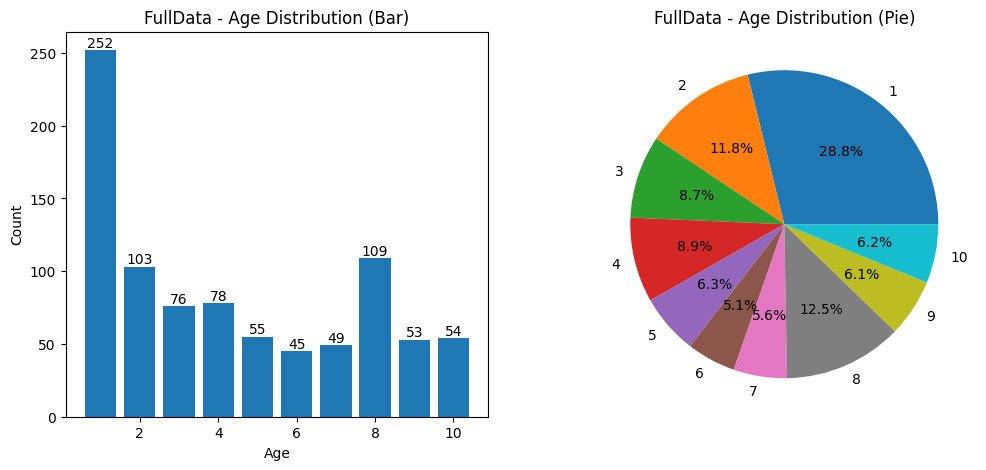

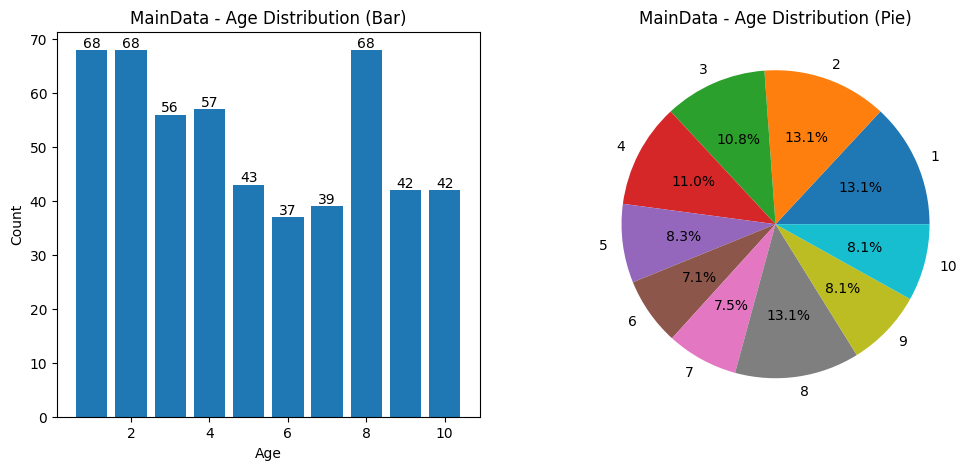

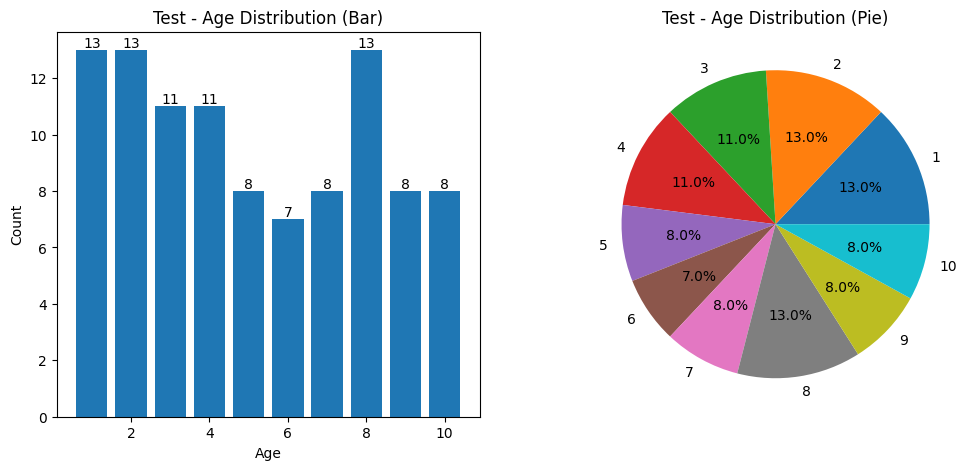

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# CONFIG
BASE_PATH = r"D:\HCSDLDPT\BTL\dataset"
folders = ["FullData", "MainData", "Test"]

for folder in folders:
    path = os.path.join(BASE_PATH, folder, "index.csv")

    if not os.path.exists(path):
        print(f"{folder}: không có index.csv")
        continue

    df = pd.read_csv(path)

    # Đếm số lượng theo tuổi
    age_counts = df["age"].value_counts().sort_index()

    # FIGURE CHUNG
    plt.figure(figsize=(12, 5))

    # BIỂU ĐỒ CỘT
    plt.subplot(1, 2, 1)
    plt.bar(age_counts.index, age_counts.values)
    plt.title(f"{folder} - Age Distribution (Bar)")
    plt.xlabel("Age")
    plt.ylabel("Count")

    # Hiển thị số trên cột (optional nhưng nên có)
    for x, y in zip(age_counts.index, age_counts.values):
        plt.text(x, y, str(y), ha='center', va='bottom')

    # BIỂU ĐỒ TRÒN
    plt.subplot(1, 2, 2)
    plt.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%')
    plt.title(f"{folder} - Age Distribution (Pie)")

    # # ===== Lưu ảnh =====
    # plt.tight_layout()
    # plt.savefig(os.path.join(BASE_PATH, f"{folder}_bar_pie.png"))
    # plt.close()

    print(f"{folder}: Done")